# EDA ② 방위사업청 국내조달 계약정보 (A3, `15050920`) — 1만 건 요건 데이터

작성 2026-09-19 · 산출물 4 「전처리 및 EDA 보고서」 중 조달 편

| 항목 | 내용 |
|---|---|
| 원본 | `data/raw/dapa/dapa_domestic_contract_20251231.csv` (cp949, 28열) |
| 비교용 | `data/raw/dapa/dapa_overseas_contract_20251231.csv` (국외조달 계약, 14열, 금액 열 없음) |
| 기간 | 계약체결일 2024-11-01 ~ 2025-12-31 (2024는 11·12월 두 달뿐 — **부분연도**) |
| 정제 규칙 | `docs/reference/data-cleaning-rules.md` §2-2, 5분류 규칙 초안 `docs/reference/contract-class5-rules.md` + `data/reference/contract_class5_rules.csv` |

**해석 경계**: 국방부(부대)·방위사업청이 **국내 업체와 맺은 모든 계약**이다(급식·시설·사무용품 포함). "전자부품 계약 1만 건"이 아니다. 계약명은 품명이 아니라 계약 제목이며, 국내 업체 계약은 **국산 제조의 증거가 아니다**. 조달 금액 ≠ 방산 매출.

**개인정보**: 담당자명 2열·대표자명은 읽자마자 버리고 출력하지 않는다. 주소는 시도 단위로만 쓴다.

목차: 1 적재·점검 → 2 전처리(차수·금액·5분류) → 3 기술통계 → 4 추세 → 5 비교 → 6 구성 → 7 관계 → 8 공간 → 9 차이검정 → 10 상관분석 → 11 요약·한계

In [1]:
import re, platform, warnings
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression")
ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
RAW = ROOT / "data" / "raw" / "dapa"
REF = ROOT / "data" / "reference"

plt.rcParams["font.family"] = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30, "display.width", 180, "display.float_format", "{:,.2f}".format)

PRIVATE_COLS = ["계약기관담당자명", "수요기관담당자명", "대표업체대표자명"]   # 출력 금지
C_MAIN, C_SUB = "#2a6fdb", "#d9534f"
CLASS5_ORDER = ["방산 장비·부품 후보", "정비·기술지원", "일반 군수물자", "일반 행정·운영", "판단 보류"]
CLASS5_COLOR = dict(zip(CLASS5_ORDER, ["#2a6fdb", "#e07b39", "#5a9e6f", "#9b8ec4", "#b0b0b0"]))

## 1. 적재·기본 점검

In [2]:
raw = pd.read_csv(RAW / "dapa_domestic_contract_20251231.csv", encoding="cp949", dtype=str)
print(f"원본 전체: {len(raw):,}행 × {raw.shape[1]}열")
print("계약체결일 범위:", raw["계약체결일자"].min(), "~", raw["계약체결일자"].max())
print("연도별 행 수:", raw["계약체결일자"].str[:4].value_counts().sort_index().to_dict())

prof = pd.DataFrame({"결측": raw.isna().sum(), "결측률": raw.isna().mean(), "고유값 수": raw.nunique()})
prof["비고"] = np.where(prof["고유값 수"] == 1, "상수 열(분석 정보 없음)", "")
prof.loc[PRIVATE_COLS, "비고"] = "개인정보 — 출력·분석 제외"
prof.style.format({"결측률": "{:.1%}"})

원본 전체: 43,112행 × 28열
계약체결일 범위: 2024-11-01 ~ 2025-12-31
연도별 행 수: {'2024': 12304, '2025': 30808}


,결측,결측률,고유값 수,비고
계약번호,0,0.0%,37608,
계약차수,0,0.0%,19,
계약명,0,0.0%,35344,
업무구분명,0,0.0%,2,
계약체결형태명,0,0.0%,2,
계약체결방법명,0,0.0%,8,
공동계약여부,0,0.0%,2,
계약체결일자,0,0.0%,397,
계약기간,0,0.0%,14715,
계약금액,0,0.0%,29634,


In [3]:
d = raw.drop(columns=PRIVATE_COLS).copy()
d["seq"] = d["계약차수"].str.zfill(2)                                   # '0'/'00' 혼재 → 2자리
d["date"] = pd.to_datetime(d["계약체결일자"])
for src, dst in [("계약금액", "amt"), ("총계약금액", "amt_total"), ("예정가격", "est_price")]:
    d[dst] = pd.to_numeric(d[src], errors="coerce")
per = d["계약기간"].str.split("~", expand=True)
d["p_start"], d["p_end"] = pd.to_datetime(per[0], errors="coerce"), pd.to_datetime(per[1], errors="coerce")
d["period_days"] = (d.p_end - d.p_start).dt.days

# 테스트 업체: 대표업체명 **정확 일치**만(정제 노트북 clean_p4_domestic 과 같은 규칙, P2 검수 2026-09-19).
# '테스트'가 든 실제 업체·품명(이테스트 주식회사·결함테스트기 등)은 키워드로 거르지 않는다
TEST_VENDORS = ["조달테스트업체Ⅰ", "테스트업체1"]
key = ["계약번호", "seq"]
dup_key = d[d.duplicated(key, keep=False)]
checks = {
    "완전 중복 행": int(raw.duplicated().sum()),
    "계약차수 원문 '0'(1자리)": int((raw["계약차수"] == "0").sum()),
    "키(계약번호+차수) 중복 행": len(dup_key),
    "키 중복 키 수": dup_key[key].drop_duplicates().shape[0],
    "계약번호 고유 수": d["계약번호"].nunique(),
    "금액 변환 실패(계약금액)": int(d.amt.isna().sum()),
    "총계약금액 결측": int(d.amt_total.isna().sum()),
    "계약기간 종료 < 시작": int((d.period_days < 0).sum()),
    "계약금액 0 이하": int((d.amt <= 0).sum()),
    "테스트 업체 행(업체명 정확 일치)": int(d["대표업체명"].isin(TEST_VENDORS).sum()),
}
display(pd.Series(checks, name="값").to_frame())
# 충돌 키: 어느 열이 다른지만 보여 준다(규칙: 지우지 않고 기록)
rk = raw.assign(seq=raw["계약차수"].str.zfill(2))
rk = rk[rk.duplicated(["계약번호", "seq"], keep=False)]
diffcols = [c for c in raw.columns if rk.groupby(["계약번호", "seq"])[c].nunique(dropna=False).max() > 1]
print("키 중복 행에서 값이 다른 열(이름만, 값은 출력하지 않음):", diffcols)
dup_key[key + ["계약명", "계약체결일자", "계약금액", "총계약금액"]]

,값
완전 중복 행,0
계약차수 원문 '0'(1자리),837
키(계약번호+차수) 중복 행,2
키 중복 키 수,1
계약번호 고유 수,37608
금액 변환 실패(계약금액),0
총계약금액 결측,1
계약기간 종료 < 시작,0
계약금액 0 이하,34
테스트 업체 행(업체명 정확 일치),6


키 중복 행에서 값이 다른 열(이름만, 값은 출력하지 않음): ['계약기관담당자명', '수요기관담당자명']


,계약번호,seq,계약명,계약체결일자,계약금액,총계약금액
15465,2024UMM1504,01,(246302-C) 피아식별IR 제조,2025-02-24,4118695830,4119506000
15466,2024UMM1504,01,(246302-C) 피아식별IR 제조,2025-02-24,4118695830,4119506000


## 2. 전처리

규칙(`data-cleaning-rules` §2-2):
1. 차수 `'0'`/`'00'` → 2자리 통일. 충돌 키(1키 2행)는 **지우지 않고** `seq_conflict_flag`로 표시하고, 계약 단위 집계의 대표 행은 원본 순서가 앞선 행으로 둔다.
2. **테스트 업체 6행 제외**: 대표업체명이 정확히 `조달테스트업체Ⅰ`(2행)·`테스트업체1`(4행)인 행은 사업자번호·주소까지 가짜인 자리표시 행이라 `is_latest_seq` 계산 전에 뺀다(DB `clean_excluded_row` PLACEHOLDER와 같은 규칙 → `clean_dapa_contract` 43,105행 / 계약 단위 37,602와 맞춘다). 원본 단위 점검(1절·위 점검표)은 빼기 전 43,112행 기준이다.
3. `is_latest_seq`: 계약번호당 최종 차수 1행. **계약 단위 금액 = 최종 차수의 `총계약금액`**(`계약금액`은 해당 차수분이라 합산하면 중복).
4. 계약 월 = 최초 체결월(`MIN(계약체결일자)`). 변경계약은 최초 월에 최종 금액으로 잡힌다.
5. 5분류 `class5`와 속성 3종(`is_electronic`·`is_part`·`is_defense_related`)은 규칙표 **초안**을 적용한 **후보**다(검수 전). `negative_pattern` 적용 방식은 아래 코드 주석에 적었다 — 정제 노트북이 다르게 정하면 그쪽이 기준이다.

In [4]:
d["row_order"] = np.arange(len(d))
n_test = int(d["대표업체명"].isin(TEST_VENDORS).sum())
d = d[~d["대표업체명"].isin(TEST_VENDORS)].copy()                        # 테스트 업체 제외(is_latest_seq 계산 전)
d["seq_conflict_flag"] = d.duplicated(key, keep=False).astype(int)
d = d.sort_values(["계약번호", "seq", "row_order"])
dd = d[~d.duplicated(key, keep="first")].copy()                        # 충돌 키의 두 번째 행은 집계에서만 제외
dd["is_latest_seq"] = ~dd.duplicated("계약번호", keep="last")
first_date = dd.groupby("계약번호").date.min().rename("first_date")
n_seq = dd.groupby("계약번호").size().rename("n_seq")
ct = dd[dd.is_latest_seq].set_index("계약번호").join(first_date).join(n_seq).reset_index()
ct["contract_amt"] = ct.amt_total.fillna(ct.amt)                        # 총계약금액 결측 행은 계약금액으로 대체
ct["first_ym"] = ct.first_date.dt.to_period("M")
ct["award_ratio"] = ct.amt / ct.est_price                               # 최종 차수 계약금액/예정가격 (참고)
ct["is_private"] = ct["계약체결방법명"].eq("수의계약")
print(f"테스트 업체 제외 {n_test}행 → 충돌 키 둘째 행 제외 후 {len(dd):,}행 (DB clean_dapa_contract 43,105)")
print(f"계약 단위(최종 차수) {len(ct):,}건 / 차수 2개 이상인 계약 {int((ct.n_seq > 1).sum()):,}건")
print(f"총계약금액 결측으로 계약금액 대체: {int(ct.amt_total.isna().sum())}건")

테스트 업체 제외 6행 → 충돌 키 둘째 행 제외 후 43,105행 (DB clean_dapa_contract 43,105)
계약 단위(최종 차수) 37,602건 / 차수 2개 이상인 계약 4,101건
총계약금액 결측으로 계약금액 대체: 1건


In [5]:
# 5분류·속성 — 규칙표 순서대로 첫 일치 확정 (Python re, 대소문자 무시)
rules = pd.read_csv(REF / "contract_class5_rules.csv", dtype=str).fillna("")
R = {r.rule_id: r for r in rules.itertuples()}
COL = {"contract_name": "계약명", "contract_org_name": "수요기관명", "biz_type_name": "업무구분명"}
PART = R["K_P"].pattern

def hit(rule, df):
    # negative_pattern 적용 방식(EDA용 결정): R4 는 행 단위 제외(규칙 문서의 '구매·제조… 없음' 조건),
    # 그 밖(R1·E1)은 복합어 안의 부분 문자열(정비대대·전자레인지 등)을 지운 뒤 pattern 을 검사한다.
    s = df[COL[rule.input_col]].fillna("")
    if rule.negative_pattern and rule.rule_id != "R4":
        s = s.str.replace(rule.negative_pattern, " ", regex=True, flags=re.I)
    m = s.str.contains(rule.pattern, regex=True, flags=re.I)
    if rule.rule_id == "R4":
        m &= ~s.str.contains(rule.negative_pattern, regex=True, flags=re.I) & s.str.contains(PART, regex=True, flags=re.I)
    if rule.scope == "물품":
        m &= df["업무구분명"].eq("물품")
    return m

def apply_class5(df):
    out = pd.Series(pd.NA, index=df.index, dtype="object"); rid = out.copy()
    for r in rules[rules.target_col == "class5"].sort_values("order", kind="stable").itertuples():
        m = out.isna() & (hit(r, df) if r.pattern else True)
        out[m], rid[m] = r.value, r.rule_id
    return out, rid

def apply_attr(df, c5, target):
    out = pd.Series(pd.NA, index=df.index, dtype="object")
    for r in rules[rules.target_col == target].sort_values("order", kind="stable").itertuples():
        if r.pattern:
            m = hit(r, df)
        elif "class5 in" in r.extra_condition:
            m = c5.isin(re.search(r"\{(.*)\}", r.extra_condition).group(1).split(", "))
            if "not E1" in r.extra_condition:
                m &= ~hit(R["E1"], df)
        else:
            m = pd.Series(True, index=df.index)
        out[out.isna() & m] = r.value
    return out

for df in (dd, ct):
    df["class5"], df["class5_rule"] = apply_class5(df)
    for a in ["is_electronic", "is_part", "is_defense_related"]:
        df[a] = apply_attr(df, df["class5"], a)

split = dd.groupby("계약번호").class5.nunique()
print("같은 계약번호 안에서 차수별 class5 가 갈리는 계약:", int((split > 1).sum()))
print("규칙별 적용 건수(계약 단위):", ct.class5_rule.value_counts().to_dict())
n_row = int(dd.class5.eq("방산 장비·부품 후보").sum()); n_row_r34 = int(dd.class5_rule.isin(["R3a", "R3b", "R4"]).sum())
print(f"행 단위(차수 포함 {len(dd):,}행) 방산 후보 {n_row:,} (R3c 계약기관 포함) / R3a·R3b·R4만 {n_row_r34:,} — 규칙 문서 측정치 2,804행(R3+R4)과 비교")
pd.crosstab(ct.class5, ct.is_electronic, margins=True).reindex(CLASS5_ORDER + ["All"])

같은 계약번호 안에서 차수별 class5 가 갈리는 계약: 0
규칙별 적용 건수(계약 단위): {'R2': 16369, 'R7': 11164, 'R1': 3724, 'R6': 2608, 'R3a': 2028, 'R5': 1263, 'R3c': 414, 'R3b': 27, 'R4': 5}
행 단위(차수 포함 43,105행) 방산 후보 2,740 (R3c 계약기관 포함) / R3a·R3b·R4만 2,326 — 규칙 문서 측정치 2,804행(R3+R4)과 비교


is_electronic,미확인,아니오,예,All
class5,,,,
방산 장비·부품 후보,2139,0,335,2474
정비·기술지원,3465,0,259,3724
일반 군수물자,0,2590,18,2608
일반 행정·운영,0,15978,391,16369
판단 보류,11605,0,822,12427
All,17209,18568,1825,37602


In [6]:
# 보고 5단계 (data-cleaning-rules §4 양식)
n_def = int((ct.class5 == "방산 장비·부품 후보").sum())
n_def_elec = int(((ct.class5 == "방산 장비·부품 후보") & (ct.is_electronic == "예")).sum())
stage = pd.DataFrame({
    "단계": ["① 원본 전체", "② 선택 연도 2025(원본 행)", "③ 중복·테스트 업체 처리 후 — 계약 단위(최종 차수)",
             "④ 관련 후보 — class5 '방산 장비·부품 후보'", "④' 그중 is_electronic='예'", "⑤ 검증된 분석 대상"],
    "건수": [f"{len(raw):,}", f"{int((raw['계약체결일자'].str[:4] == '2025').sum()):,}", f"{len(ct):,}", f"{n_def:,}", f"{n_def_elec:,}", "미확정(검수 전)"],
    "비고": ["1만 건 요건 판정 기준", "2024는 11·12월만(부분연도)", "문서 기대값 37,602 (테스트 업체 6행 제외 전 37,608)",
             "규칙 초안 적용 결과 — 후보", "전자 관련 후보", "review_status 확정 후"],
})
stage

,단계,건수,비고
0,① 원본 전체,"43,112",1만 건 요건 판정 기준
1,② 선택 연도 2025(원본 행),"30,808",2024는 11·12월만(부분연도)
2,③ 중복·테스트 업체 처리 후 — 계약 단위(최종 차수),"37,602","문서 기대값 37,602 (테스트 업체 6행 제외 전 37,608)"
3,④ 관련 후보 — class5 '방산 장비·부품 후보',"2,474",규칙 초안 적용 결과 — 후보
4,④' 그중 is_electronic='예',335,전자 관련 후보
5,⑤ 검증된 분석 대상,미확정(검수 전),review_status 확정 후


**판정** — 수량: 원본 43,112행으로 1만 건 요건 **충족**(원본 기준) / 최신 연도: 2025 완결, 2024는 11~12월만 / 주제 적합성: 방산 장비·부품 후보는 전체의 일부이고 전자 관련은 더 적다 — **전자부품 여부는 속성으로 관리**하고 1만 건과 섞지 않는다 / 연결 가능성: 관세청 HS와 공통 식별자가 없다(연결하지 않음).

## 3. 기술통계 (계약 단위)

In [7]:
g = ct.groupby("업무구분명").contract_amt
desc = pd.concat([ct.contract_amt.describe().rename("전체").to_frame().T, g.describe()])
desc["왜도"] = [stats.skew(ct.contract_amt)] + [stats.skew(x) for _, x in g]
desc["합계(억원)"] = [ct.contract_amt.sum() / 1e8] + [x.sum() / 1e8 for _, x in g]
desc.style.format("{:,.0f}").format({"왜도": "{:.1f}", "합계(억원)": "{:,.1f}"})

,count,mean,std,min,25%,50%,75%,max,왜도,합계(억원)
전체,37602.000000,421089066.700335,12406663422.112812,0.000000,4930462.500000,14435150.000000,45366265.000000,1715280000000.000000,94.7,"158,337.9"
물품,28553.000000,450102498.802998,13995168719.036163,0.000000,4011040.000000,12846000.000000,41228000.000000,1715280000000.000000,86.3,"128,517.8"
용역,9049.000000,329540771.106642,4646131046.608868,0.000000,8313710.000000,19500000.000000,59749600.000000,300290000000.000000,49.9,"29,820.1"


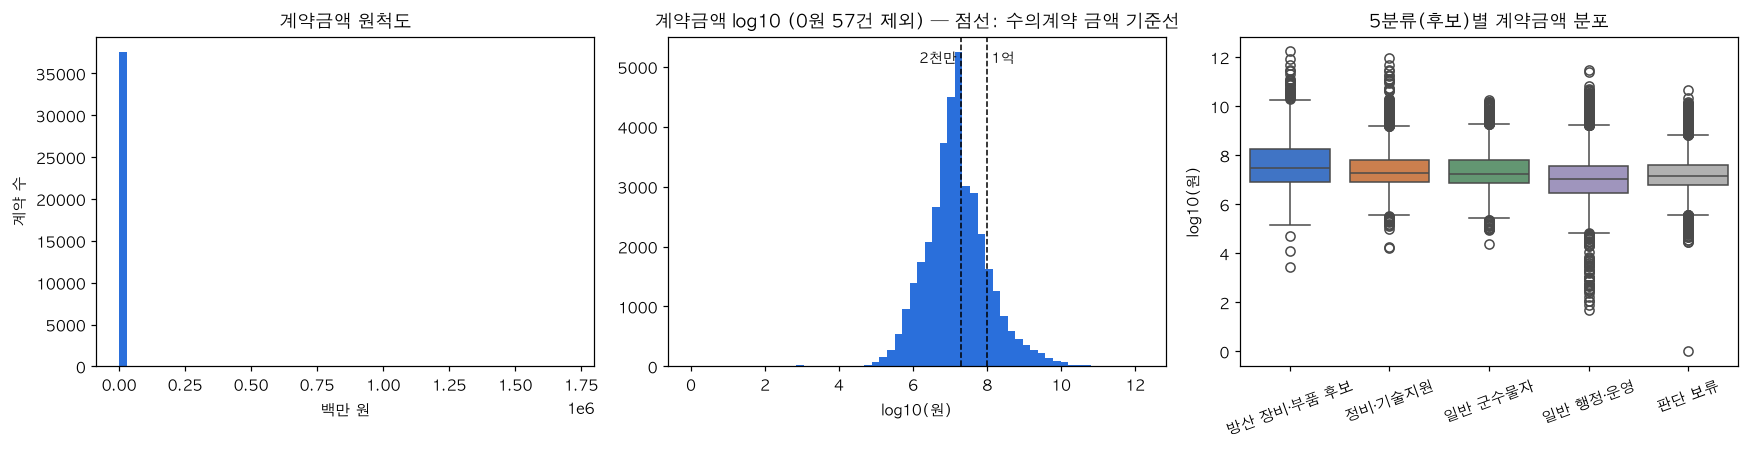

2천만 원 이하 계약 비중: 59.9% / 상위 1% 계약이 차지하는 금액 비중: 78.0%


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(ct.contract_amt / 1e6, bins=60, color=C_MAIN); ax[0].set(title="계약금액 원척도", xlabel="백만 원", ylabel="계약 수")
pos = ct[ct.contract_amt > 0]                                            # 0원 계약은 로그 척도에서 제외
ax[1].hist(np.log10(pos.contract_amt), bins=60, color=C_MAIN)
for v, lab, ha in [(2e7, "2천만 ", "right"), (1e8, " 1억", "left")]:
    ax[1].axvline(np.log10(v), ls="--", color="k", lw=1); ax[1].text(np.log10(v), ax[1].get_ylim()[1] * .92, lab, ha=ha, fontsize=9)
ax[1].set(title=f"계약금액 log10 (0원 {len(ct) - len(pos)}건 제외) — 점선: 수의계약 금액 기준선", xlabel="log10(원)")
sns.boxplot(data=pos.assign(log_amt=np.log10(pos.contract_amt)), x="class5", y="log_amt", order=CLASS5_ORDER,
            hue="class5", palette=CLASS5_COLOR, legend=False, ax=ax[2])
ax[2].set(title="5분류(후보)별 계약금액 분포", xlabel="", ylabel="log10(원)"); ax[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print("2천만 원 이하 계약 비중:", f"{(ct.contract_amt <= 2e7).mean():.1%}", "/ 상위 1% 계약이 차지하는 금액 비중:",
      f"{ct.contract_amt.nlargest(int(len(ct) * .01)).sum() / ct.contract_amt.sum():.1%}")

## 4. 추세 — 월별 계약 건수·금액 (최초 체결월 기준)

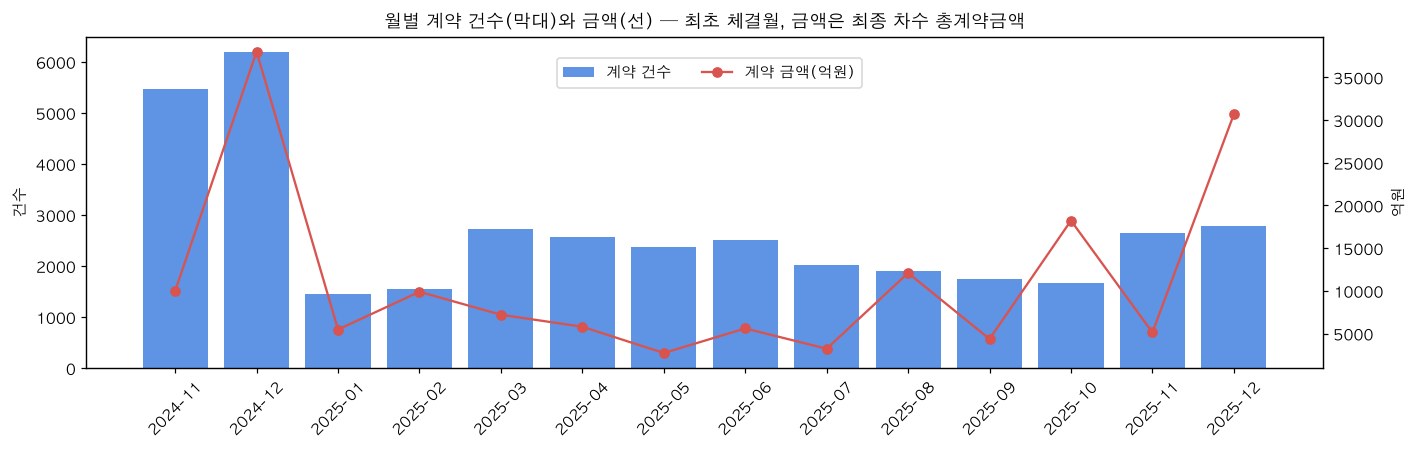

원 계약이 데이터 기간 이전인 계약(첫 관측 차수≠00): 2,406건 (6.4%)


first_ym,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
건수,"5,466","6,187","1,458","1,559","2,732","2,561","2,373","2,509","2,021","1,901","1,739","1,674","2,639","2,783"
금액_억원,"9,981","38,019","5,467","9,888","7,198","5,790","2,715","5,594","3,216","12,088","4,360","18,224","5,126","30,673"
첫 관측 차수≠00 비율,9.1%,9.8%,49.7%,12.1%,4.2%,3.3%,1.2%,1.5%,2.4%,1.0%,0.9%,0.6%,0.8%,0.4%


In [9]:
mon = ct.groupby("first_ym").agg(건수=("계약번호", "size"), 금액_억원=("contract_amt", lambda s: s.sum() / 1e8))
fig, ax1 = plt.subplots(figsize=(13, 4.2))
x = mon.index.astype(str)
ax1.bar(x, mon.건수, color=C_MAIN, alpha=.75, label="계약 건수")
ax2 = ax1.twinx(); ax2.plot(x, mon.금액_억원, color=C_SUB, marker="o", label="계약 금액(억원)")
ax1.set(title="월별 계약 건수(막대)와 금액(선) — 최초 체결월, 금액은 최종 차수 총계약금액", ylabel="건수"); ax2.set_ylabel("억원")
ax1.tick_params(axis="x", rotation=45); fig.legend(loc="upper center", bbox_to_anchor=(.5, .88), ncol=2); plt.tight_layout(); plt.show()
# '최초 체결월'은 이 데이터 안에서 처음 관측된 월이다. 첫 관측 차수가 00이 아니면 원 계약이 2024-11 이전에 체결된 것
min_seq = dd.groupby("계약번호").seq.min()
ct["starts_mid"] = ct["계약번호"].map(min_seq).ne("00")
mon["첫 관측 차수≠00 비율"] = ct.groupby("first_ym").starts_mid.mean()
print(f"원 계약이 데이터 기간 이전인 계약(첫 관측 차수≠00): {int(ct.starts_mid.sum()):,}건 ({ct.starts_mid.mean():.1%})")
mon.T.style.format("{:,.0f}").format("{:.1%}", subset=pd.IndexSlice["첫 관측 차수≠00 비율", :])

## 5. 비교 — 계약체결방법·수의계약 사유

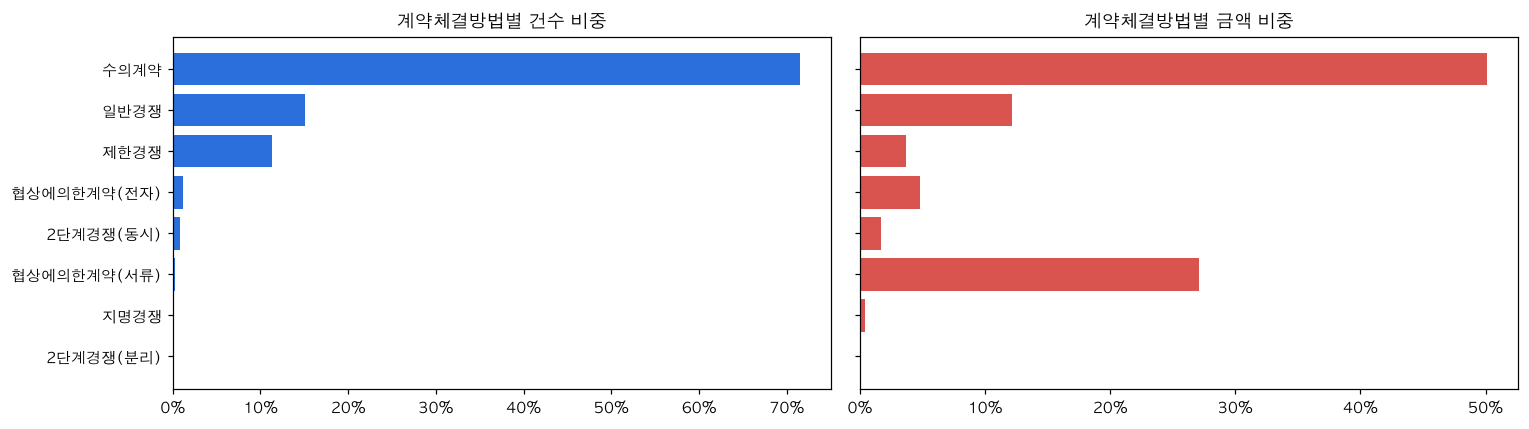

,건수,금액_억원,건수비중,금액비중
계약체결방법명,,,,
수의계약,26868,"79,312.1",71.5%,50.1%
일반경쟁,5657,"19,288.0",15.0%,12.2%
제한경쟁,4236,"5,782.0",11.3%,3.7%
협상에의한계약(전자),425,"7,630.3",1.1%,4.8%
2단계경쟁(동시),300,"2,703.7",0.8%,1.7%
협상에의한계약(서류),82,"42,883.8",0.2%,27.1%
지명경쟁,25,664.0,0.1%,0.4%
2단계경쟁(분리),9,74.0,0.0%,0.0%


In [10]:
meth = ct.groupby("계약체결방법명").agg(건수=("계약번호", "size"), 금액_억원=("contract_amt", lambda s: s.sum() / 1e8))
meth["건수비중"] = meth.건수 / meth.건수.sum(); meth["금액비중"] = meth.금액_억원 / meth.금액_억원.sum()
meth = meth.sort_values("건수", ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
ax[0].barh(meth.index[::-1], meth.건수비중[::-1], color=C_MAIN); ax[0].set(title="계약체결방법별 건수 비중")
ax[1].barh(meth.index[::-1], meth.금액비중[::-1], color=C_SUB); ax[1].set(title="계약체결방법별 금액 비중")
for a in ax: a.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()
meth.style.format({"금액_억원": "{:,.1f}", "건수비중": "{:.1%}", "금액비중": "{:.1%}"})

In [11]:
# 수의계약 사유 — 조문 번호를 떼고 핵심 문구로 묶어 상위 8개
rs = ct.loc[ct.is_private, "수의계약사유"].fillna("(사유 없음)")
rs_short = rs.str.replace(r"^국계법시행령\s*제\d+조(?:제\d+항)?(?:제\d+호)?\s*", "", regex=True).str.slice(0, 45)
top = rs_short.value_counts()
print(f"수의계약 {int(ct.is_private.sum()):,}건 중 사유 상위 8개가 {top.head(8).sum() / top.sum():.1%}")
top.head(8).rename("건수").to_frame()

수의계약 26,868건 중 사유 상위 8개가 94.5%


,건수
수의계약사유,
"가목 2) 추정가격 2천만원이하(제조, 구매, 용역)",17496
"가목 3) 추정가격 2천만원 초과 1억원 이하(소기업, 소상공인)",3635
바목 우수조달물품,1064
"바목 국가기관, 지방자치단체와 계약",987
재공고후 수의계약,818
기재부 고시에 따른 공고 후 1인입찰 후 수의계약,722
가목 5) 추정가격 2천만원 초과 1억원 이하(여성기업 등),356
마목 다른 법령의 규정에 의하여 국가사업을 위탁 또는 대행,300


## 6. 구성 — 5분류(후보) 건수·금액 구성

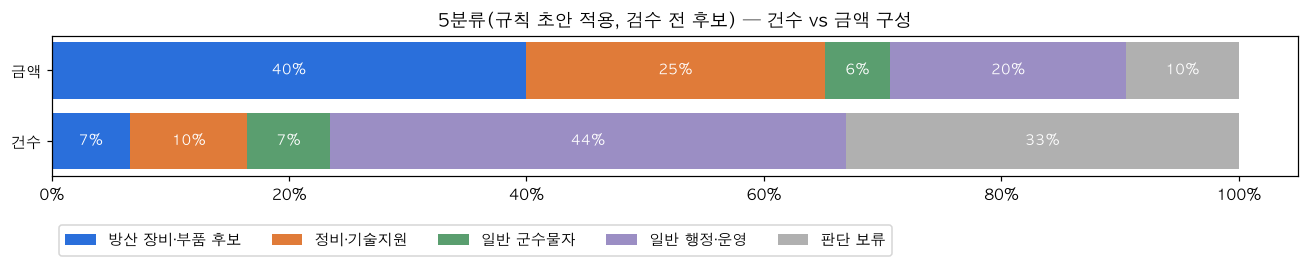

,건수,건수비중,금액비중,금액_억원
class5,,,,
방산 장비·부품 후보,2474,6.6%,40.0%,"63,282.3"
정비·기술지원,3724,9.9%,25.1%,"39,812.4"
일반 군수물자,2608,6.9%,5.5%,"8,748.7"
일반 행정·운영,16369,43.5%,19.9%,"31,437.1"
판단 보류,12427,33.0%,9.5%,"15,057.5"


In [12]:
comp = ct.groupby("class5").agg(건수=("계약번호", "size"), 금액=("contract_amt", "sum")).reindex(CLASS5_ORDER)
share = comp / comp.sum()
fig, ax = plt.subplots(figsize=(12, 2.8))
left = np.zeros(2)
for c in CLASS5_ORDER:
    ax.barh(["건수", "금액"], share.loc[c], left=left, color=CLASS5_COLOR[c], label=c)
    for i, v in enumerate(share.loc[c]):
        if v > .04: ax.text(left[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9)
    left += share.loc[c].values
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("5분류(규칙 초안 적용, 검수 전 후보) — 건수 vs 금액 구성"); ax.legend(ncol=5, bbox_to_anchor=(0, -.3), loc="upper left")
plt.tight_layout(); plt.show()
comp.assign(건수비중=share.건수, 금액비중=share.금액, 금액_억원=comp.금액 / 1e8).drop(columns="금액").style.format(
    {"건수비중": "{:.1%}", "금액비중": "{:.1%}", "금액_억원": "{:,.1f}"})

## 7. 관계 — 예정가격 vs 계약금액, 계약기간 vs 금액

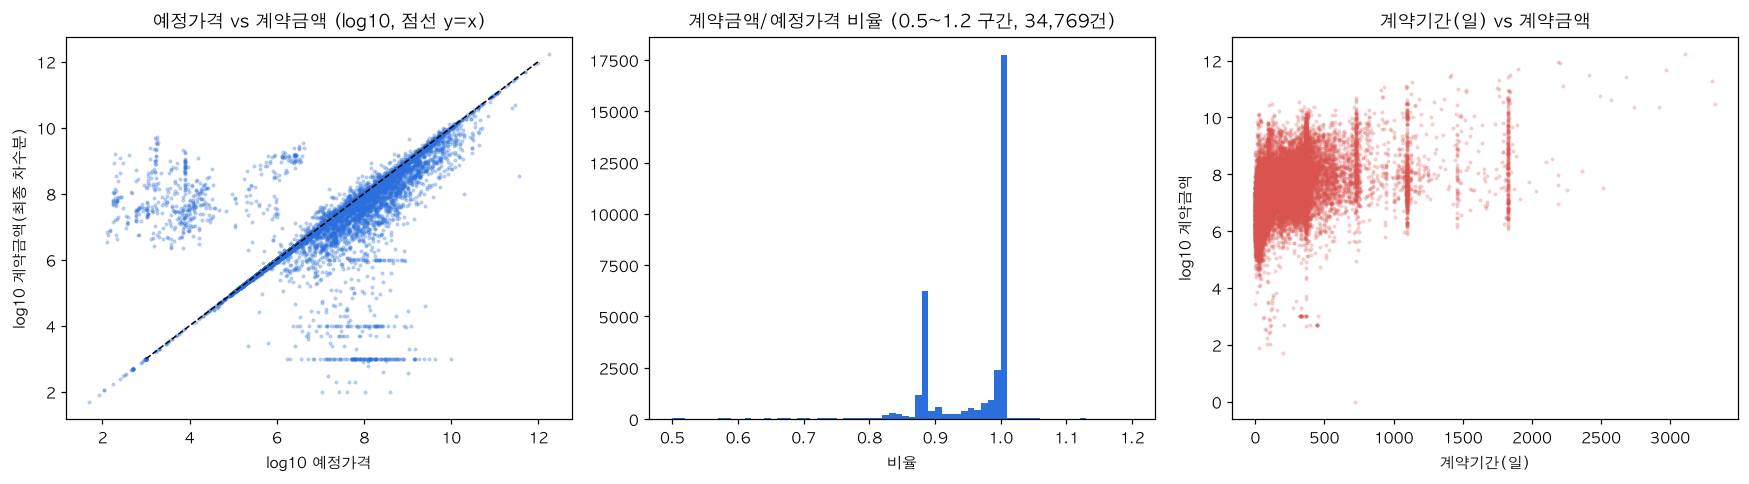

비율 중앙값: 1.0 / 비율 1 초과: 1349 건 / 0.5~1.2 밖: 2741 건


In [13]:
r = ct[(ct.est_price > 0) & (ct.amt > 0)]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(np.log10(r.est_price), np.log10(r.amt), s=3, alpha=.25, color=C_MAIN)
lim = [3, 12]; ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set(title="예정가격 vs 계약금액 (log10, 점선 y=x)", xlabel="log10 예정가격", ylabel="log10 계약금액(최종 차수분)")
rr = r.award_ratio[r.award_ratio.between(.5, 1.2)]
ax[1].hist(rr, bins=70, color=C_MAIN); ax[1].set(title=f"계약금액/예정가격 비율 (0.5~1.2 구간, {len(rr):,}건)", xlabel="비율")
p = ct[ct.period_days.between(0, 3650)]
p = p[p.contract_amt > 0]
ax[2].scatter(p.period_days, np.log10(p.contract_amt), s=3, alpha=.2, color=C_SUB)
ax[2].set(title="계약기간(일) vs 계약금액", xlabel="계약기간(일)", ylabel="log10 계약금액")
plt.tight_layout(); plt.show()
print("비율 중앙값:", round(r.award_ratio.median(), 4), "/ 비율 1 초과:", int((r.award_ratio > 1).sum()), "건",
      "/ 0.5~1.2 밖:", int((~r.award_ratio.between(.5, 1.2)).sum()), "건")

## 8. 공간 — 계약업체 소재 시도

주소 첫 토큰 → 시도는 `db/seed_ref.sql`의 `ref_sido_map` 행을 그대로 읽어 쓴다(정본 한 곳). **계약업체 소재지**이지 생산·납품 위치가 아니다.

ref_sido_map 토큰 44개 / 시도 미상: {'1': 1, '**': 1}


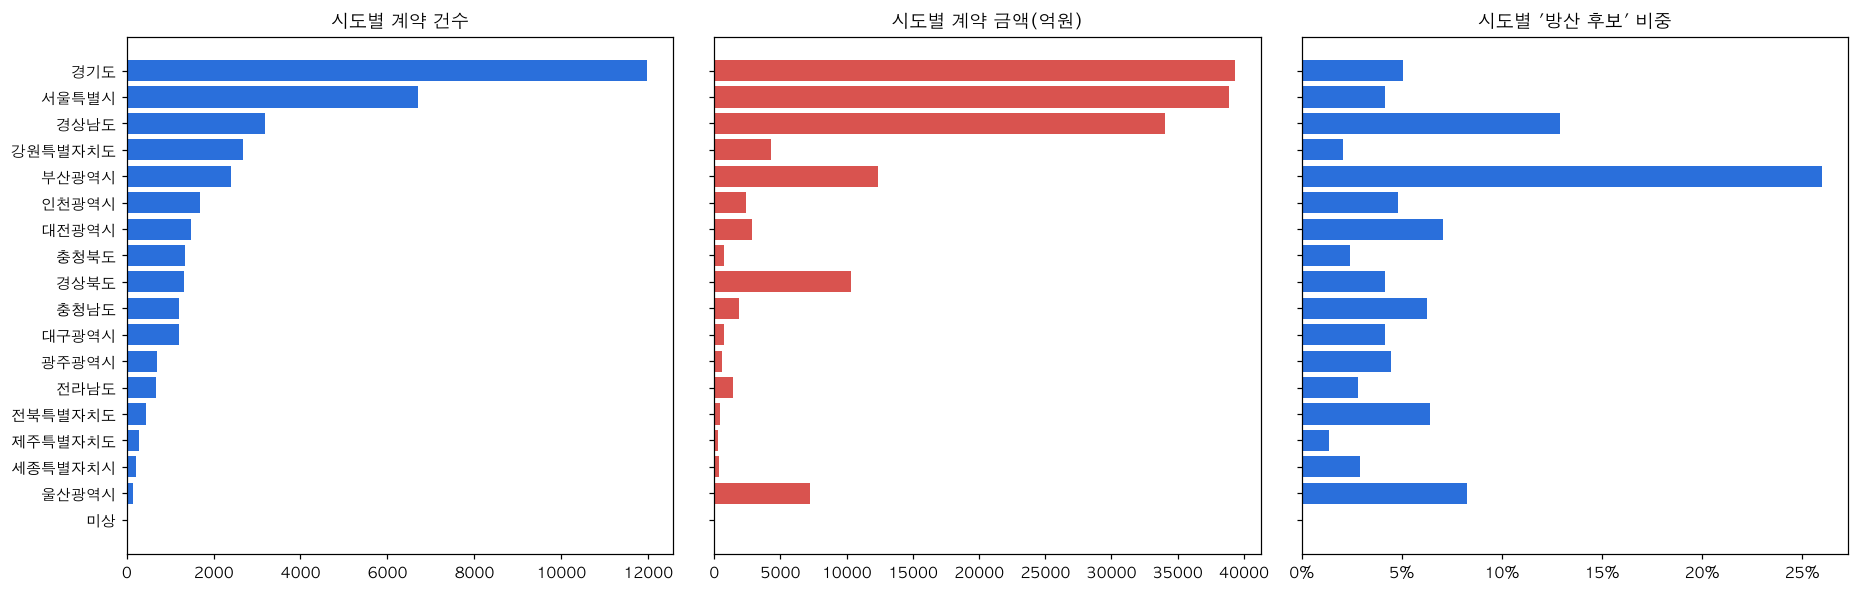

,건수,금액_억원,방산후보,방산후보비중
sido,,,,
경기도,11978,"39,292.9",605,5.1%
서울특별시,6697,"38,847.6",280,4.2%
경상남도,3180,"34,068.9",410,12.9%
강원특별자치도,2676,"4,308.7",55,2.1%
부산광역시,2404,"12,408.0",625,26.0%
인천광역시,1680,"2,422.5",81,4.8%
대전광역시,1488,"2,872.1",105,7.1%
충청북도,1334,744.3,32,2.4%
경상북도,1315,"10,324.0",55,4.2%


In [14]:
seed = (ROOT / "db" / "seed_ref.sql").read_text(encoding="utf-8")
block = seed.split("INSERT IGNORE INTO ref_sido_map")[1].split(";")[0]
sido_map = {t: n for t, _, n in re.findall(r"\('([^']+)','(\d+)','([^']+)'\)", block)}
tok = ct["대표업체주소"].str.split()
ct["sido"] = tok.str[0].map(sido_map)
# 광주 둘째 토큰 규칙 (docs/report/ref-review-p2-2026-09-18.md §3): 광역시 구 → 광주광역시, 읍·면 → 경기도, 그 외 판별 불가
gj = tok.str[0].isin(["광주", "광주시"])
ct.loc[gj & tok.str[1].isin(["동구", "서구", "남구", "북구", "광산구"]), "sido"] = "광주광역시"
ct.loc[gj & tok.str[1].str.contains(r"[읍면]$", na=False), "sido"] = "경기도"
ct["sido"] = ct["sido"].fillna("미상")
print(f"ref_sido_map 토큰 {len(sido_map)}개 / 시도 미상:", ct.loc[ct.sido == "미상", "대표업체주소"].str.split().str[0].value_counts(dropna=False).to_dict())

sd = ct.groupby("sido").agg(건수=("계약번호", "size"), 금액_억원=("contract_amt", lambda s: s.sum() / 1e8),
                            방산후보=("class5", lambda s: (s == "방산 장비·부품 후보").sum()))
sd["방산후보비중"] = sd.방산후보 / sd.건수
sd = sd.sort_values("건수")
fig, ax = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
ax[0].barh(sd.index, sd.건수, color=C_MAIN); ax[0].set(title="시도별 계약 건수")
ax[1].barh(sd.index, sd.금액_억원, color=C_SUB); ax[1].set(title="시도별 계약 금액(억원)")
ax[2].barh(sd.index, sd.방산후보비중, color=CLASS5_COLOR["방산 장비·부품 후보"]); ax[2].set(title="시도별 '방산 후보' 비중")
ax[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()
sd.sort_values("건수", ascending=False).style.format({"금액_억원": "{:,.1f}", "방산후보비중": "{:.1%}"})

## 9. 차이검정 · 교차분석

유의수준 α = 0.05. 금액은 치우친 분포라 **비모수 검정**을 쓴다(정규성 검정은 n이 수만 건이면 거의 항상 기각되므로 3절 왜도로 판단). n이 크면 작은 차이도 유의해지므로 **효과크기**를 함께 본다.

| 가설 | 비교 | 검정 |
|---|---|---|
| H1 | 업무구분(물품/용역) × 수의계약 여부 | χ² 독립성 + Cramér's V |
| H2 | 국내조달 vs 국외조달 계약의 수의계약 비율 (같은 기간 2024-11~2025-12) | χ² 독립성 + Cramér's V |
| H3 | 계약금액: 수의계약 vs 경쟁계약 | Mann-Whitney U |
| H4 | 계약금액: 5분류(후보) 5개 집단 | Kruskal-Wallis → 사후 쌍별 Mann-Whitney(Bonferroni) |

In [15]:
def chi2_report(name, tab):
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    return {"가설": name, "n": int(tab.values.sum()), "통계량": chi2, "자유도": dof, "p값": p, "효과크기": v,
            "효과크기 종류": "Cramér's V", "최소 기대빈도": exp.min(), "판정(α=.05)": "유의" if p < .05 else "유의하지 않음"}

tab1 = pd.crosstab(ct["업무구분명"], ct.is_private).rename(columns={True: "수의", False: "경쟁 등"})
ov = pd.read_csv(RAW / "dapa_overseas_contract_20251231.csv", dtype=str)
n_ov_test = int(ov["대표업체명"].eq("TEST2").sum())
ov = ov[~ov["대표업체명"].eq("TEST2")]   # 국외조달 테스트 계약 6행(2017~2019) 제외 — 정확 일치, DB clean_dapa_overseas_contract 6,327과 같은 기준(P3 검수 2026-09-20)
ov_same = ov[ov["계약체결일자"].between("2024-11-01", "2025-12-31")]
dom_p, ov_p = dd["계약체결방법명"].eq("수의계약"), ov_same["계약체결방법명"].eq("수의계약")
tab2 = pd.DataFrame({"수의": [dom_p.sum(), ov_p.sum()], "경쟁 등": [(~dom_p).sum(), (~ov_p).sum()]}, index=["국내조달", "국외조달"])
display(tab1.assign(수의비율=lambda x: x["수의"] / x.sum(axis=1)).style.format({"수의비율": "{:.1%}"}))
display(tab2.assign(수의비율=lambda x: x["수의"] / x.sum(axis=1)).style.format({"수의비율": "{:.1%}"}))
print(f"국외조달 테스트 계약 제외: {n_ov_test}행 (비교 기간 밖이라 H2 표본에는 영향 없음)")
print(f"참고: 국외조달 전 기간(2017~2025) 수의 비율 {ov['계약체결방법명'].eq('수의계약').mean():.1%} (n={len(ov):,}), 같은 기간 n={len(ov_same):,}")

priv, comp_ = ct.loc[ct.is_private, "contract_amt"], ct.loc[~ct.is_private, "contract_amt"]
mw = stats.mannwhitneyu(priv, comp_, alternative="two-sided")
groups = [ct.loc[ct.class5 == c, "contract_amt"] for c in CLASS5_ORDER]
kw = stats.kruskal(*groups)
eps2 = (kw.statistic - len(groups) + 1) / (len(ct) - len(groups))       # Kruskal-Wallis 효과크기 ε²
res = [chi2_report("H1 업무구분 × 수의계약 여부 (계약 단위)", tab1),
       chi2_report("H2 국내 vs 국외조달 × 수의계약 여부 (차수 포함 행, 같은 기간)", tab2),
       {"가설": "H3 계약금액 수의(A) vs 경쟁(B)", "n": len(ct), "통계량": mw.statistic, "자유도": np.nan, "p값": mw.pvalue,
        "효과크기": 2 * mw.statistic / (len(priv) * len(comp_)) - 1, "효과크기 종류": "순위이연 상관",
        "최소 기대빈도": np.nan, "판정(α=.05)": "유의" if mw.pvalue < .05 else "유의하지 않음"},
       {"가설": "H4 계약금액 5분류(후보) 간", "n": len(ct), "통계량": kw.statistic, "자유도": len(groups) - 1, "p값": kw.pvalue,
        "효과크기": eps2, "효과크기 종류": "ε²", "최소 기대빈도": np.nan, "판정(α=.05)": "유의" if kw.pvalue < .05 else "유의하지 않음"}]
tests = pd.DataFrame(res)
print(f"H3 중앙값: 수의 {priv.median():,.0f}원 / 경쟁 {comp_.median():,.0f}원")
tests.style.format({"통계량": "{:,.1f}", "p값": "{:.3g}", "효과크기": "{:+.3f}", "최소 기대빈도": "{:,.1f}", "자유도": "{:.0f}"}, na_rep="—")

is_private,경쟁 등,수의,수의비율
업무구분명,,,
물품,8812,19741,69.1%
용역,1922,7127,78.8%


,수의,경쟁 등,수의비율
국내조달,30249,12856,70.2%
국외조달,196,609,24.3%


국외조달 테스트 계약 제외: 6행 (비교 기간 밖이라 H2 표본에는 영향 없음)
참고: 국외조달 전 기간(2017~2025) 수의 비율 20.2% (n=6,327), 같은 기간 n=805
H3 중앙값: 수의 10,969,150원 / 경쟁 50,042,920원


,가설,n,통계량,자유도,p값,효과크기,효과크기 종류,최소 기대빈도,판정(α=.05)
0,H1 업무구분 × 수의계약 여부 (계약 단위),37602,311.4,1,1.07e-69,+0.091,Cramér's V,"2,583.2",유의
1,"H2 국내 vs 국외조달 × 수의계약 여부 (차수 포함 행, 같은 기간)",43910,778.4,1,2.66e-171,+0.133,Cramér's V,246.9,유의
2,H3 계약금액 수의(A) vs 경쟁(B),37602,"84,768,929.5",—,0,-0.412,순위이연 상관,—,유의
3,H4 계약금액 5분류(후보) 간,37602,"1,090.2",4,1.03e-234,+0.029,ε²,—,유의


In [16]:
# H4 사후: 쌍별 Mann-Whitney, Bonferroni 보정 (10쌍)
rows = []
for a, b in combinations(CLASS5_ORDER, 2):
    x, y = ct.loc[ct.class5 == a, "contract_amt"], ct.loc[ct.class5 == b, "contract_amt"]
    t = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({"A": a, "B": b, "중앙값 A(만원)": x.median() / 1e4, "중앙값 B(만원)": y.median() / 1e4,
                 "p(보정)": min(t.pvalue * 10, 1), "순위이연 상관": 2 * t.statistic / (len(x) * len(y)) - 1})
post = pd.DataFrame(rows)
post.style.format({"중앙값 A(만원)": "{:,.0f}", "중앙값 B(만원)": "{:,.0f}", "p(보정)": "{:.3g}", "순위이연 상관": "{:+.2f}"})

,A,B,중앙값 A(만원),중앙값 B(만원),p(보정),순위이연 상관
0,방산 장비·부품 후보,정비·기술지원,"2,882","1,889",7.3e-11,+0.10
1,방산 장비·부품 후보,일반 군수물자,"2,882","1,795",8.03e-12,+0.12
2,방산 장비·부품 후보,일반 행정·운영,"2,882","1,120",7.66e-128,+0.30
3,방산 장비·부품 후보,판단 보류,"2,882","1,482",2.48e-60,+0.21
4,정비·기술지원,일반 군수물자,"1,889","1,795",0.948,+0.02
5,정비·기술지원,일반 행정·운영,"1,889","1,120",2.69e-101,+0.23
6,정비·기술지원,판단 보류,"1,889","1,482",2.4e-28,+0.12
7,일반 군수물자,일반 행정·운영,"1,795","1,120",9.69e-59,+0.20
8,일반 군수물자,판단 보류,"1,795","1,482",1.32e-12,+0.09
9,일반 행정·운영,판단 보류,"1,120","1,482",3.39e-63,-0.12


## 10. 상관분석 (계약 단위, Spearman)

계약금액·예정가격·계약기간·차수 수·계약금액/예정가격 비율·수의계약 여부·방산 후보 여부 사이의 순위상관(이진 변수는 점이연 상관과 같은 방향으로 읽는다). n이 수만 건이라 작은 ρ도 p값은 매우 작다 — **p값보다 ρ의 크기**로 읽는다.

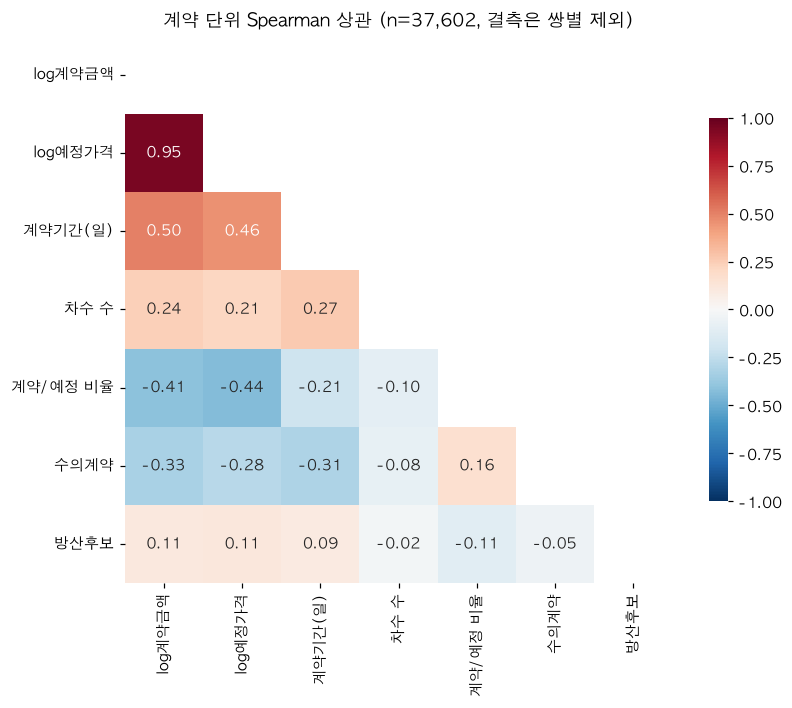

변수별 유효 n: {'log계약금액': 37545, 'log예정가격': 37536, '계약기간(일)': 37601, '차수 수': 37602, '계약/예정 비율': 34946, '수의계약': 37602, '방산후보': 37602}


ρ
log예정가격  log계약금액  0.95
계약기간(일)  log계약금액  0.50
         log예정가격  0.46
계약/예정 비율 log예정가격 -0.44
         log계약금액 -0.41
수의계약     log계약금액 -0.33
         계약기간(일) -0.31
         log예정가격 -0.28

In [17]:
feat = pd.DataFrame({
    "log계약금액": np.log10(ct.contract_amt.where(ct.contract_amt > 0)),
    "log예정가격": np.log10(ct.est_price.where(ct.est_price > 0)),
    "계약기간(일)": ct.period_days.where(ct.period_days >= 0),
    "차수 수": ct.n_seq,
    "계약/예정 비율": ct.award_ratio.where(ct.award_ratio.between(.5, 1.5)),
    "수의계약": ct.is_private.astype(int),
    "방산후보": (ct.class5 == "방산 장비·부품 후보").astype(int),
})
rho = feat.corr(method="spearman")
mask = np.triu(np.ones_like(rho, bool))
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(rho, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title(f"계약 단위 Spearman 상관 (n={len(ct):,}, 결측은 쌍별 제외)"); plt.tight_layout(); plt.show()
print("변수별 유효 n:", feat.notna().sum().to_dict())
rho.where(~mask).stack().rename("ρ").sort_values(key=abs, ascending=False).head(8).to_frame()

## 11. 요약·한계

### 발견 (모두 위 셀의 실행 결과, 2026-09-19 로컬 원본 기준)

| # | 구분 | 내용 |
|---|---|---|
| 1 | 점검 | 원본 43,112행 × 28열, 완전 중복 0. 차수 `'0'` 837행을 2자리로 통일. 키(계약번호+차수) 충돌 1개(`2024UMM1504`-`01`, 2행)는 **담당자명 2열만 다르다** → 기록만 하고 계약 단위 집계에서만 1행 사용. 계약금액 0 이하 34행. **테스트 업체 6행**(대표업체명 정확 일치 `조달테스트업체Ⅰ` 2·`테스트업체1` 4 — 사업자번호·주소도 가짜)은 계약 단위 집계 전에 제외(DB `clean_excluded_row` PLACEHOLDER와 같은 규칙). `계약기관구분명`·`수요기관구분명`·`국내업체여부`는 값이 하나뿐인 상수 열 |
| 2 | 5단계 | 원본 43,112 → 2025년 30,808 → 테스트 업체 6행·충돌 1행 제외 43,105 → 계약 단위(최종 차수) **37,602**(DB `clean_dapa_contract`·문서 기대값과 일치, 테스트 업체 제외 전 37,608) → 방산 장비·부품 후보 **2,474**(6.6%) → 그중 전자 관련 **335** → 검증된 분석 대상 **미확정**(검수 전) |
| 3 | 기술통계 | 계약금액 중앙값 약 1,444만 원, 평균 약 4.2억 원, 왜도 94.7. 2천만 원 이하 계약이 59.9%이고 **상위 1% 계약이 금액의 78.0%** 를 차지한다 |
| 4 | 추세 | 금액은 **12월에 몰린다**(2024-12 약 3.80조 원, 2025-12 약 3.07조 원). 2025-01은 첫 관측 차수가 00이 아닌 계약이 49.7% — 데이터 기간 이전에 맺은 계약의 변경 차수라서, 월별 '최초 체결월'은 "관측 최초월"로 읽어야 한다 |
| 5 | 비교 | 수의계약이 **건수 71.5%, 금액 50.1%**. 수의계약 사유의 65%(17,496건)는 "추정가격 2천만 원 이하" 소액 조항이다. 협상에 의한 계약(서류) 82건이 금액의 27.1% |
| 6 | 구성 | 방산 장비·부품 후보는 **건수 6.6%지만 금액 40.0%**. 일반 행정·운영은 건수 43.5%·금액 19.9%, 판단 보류가 건수 33.0% |
| 7 | 관계 | 예정가격과 계약금액 ρ=0.95, 계약금액/예정가격 비율 중앙값 1.0(소액 수의계약은 예정가격 그대로 계약). 계약기간과 금액 ρ=0.50 |
| 8 | 공간 | 계약업체 소재지 건수 경기 11,978·서울 6,697·경남 3,180. 방산 후보 비중은 **부산 26.0%·경남 12.9%** 로 다른 시도(1~8%)보다 높다(함정·항공 업체 소재지와 겹치는지는 **추론**, 미검증) |
| 9 | 차이검정 H1 | 용역의 수의계약 비율(78.8%)이 물품(69.1%)보다 높다. χ² p<0.001이지만 **Cramér's V=0.09로 효과는 작다** |
| 10 | 차이검정 H2 | 같은 기간 국내조달 수의계약 70.2% vs 국외조달 24.3%. χ² p<0.001, V=0.13 (국외 전 기간 기준으로는 20.2%, 테스트 계약 6행 제외 n=6,327) |
| 11 | 차이검정 H3 | 수의계약 금액 중앙값 약 1,097만 원 vs 경쟁 약 5,004만 원. Mann-Whitney p<0.001, 순위이연 상관 −0.41(**중간 크기 효과**) |
| 12 | 차이검정 H4 | 5분류 간 계약금액 차이 Kruskal-Wallis p<0.001, ε²=0.029(작은 효과). 방산 후보 중앙값(약 2,882만 원)이 가장 크다. 정비·기술지원과 일반 군수물자는 차이가 **유의하지 않다**(보정 p=0.948) |
| 13 | 상관 | 계약금액/예정가격 비율은 금액과 ρ=−0.41 — 큰 계약일수록 예정가격보다 낮게 계약된다. 수의계약 여부와 금액 ρ=−0.33 |

### 한계·주의

- **5분류는 규칙 초안을 적용한 후보**다. 표본 검수(`contract-class5-rules.md` §5) 전이라 방산 후보 2,474건을 확정값으로 쓰지 않는다. 같은 규칙표로 센 행 단위 방산 후보(2,740, R3a·R3b·R4만 2,326)가 규칙 문서 측정치 2,804행과 조금 다르며 원인은 **미확인**이다(`negative_pattern` 적용 방식 차이로 추정).
- 금액은 **최종 차수 총계약금액**이다. 계약금액(차수분)을 합산하지 않았다.
- 2024는 11·12월 두 달뿐이라 연도 비교를 하지 않았다. 12월 집중이 연례적인지는 한 해치(2025)만으로 판단할 수 없다.
- 국외조달 계약 파일에는 금액 열이 없어 H2는 **건수 비율**만 비교했다. 국외조달 쪽도 테스트 계약 6행(대표업체명 `TEST2`, 2017~2019)을 빼 DB(6,327행)와 맞췄다 — 비교 기간 밖이라 H2 결과는 변하지 않는다.
- 대표업체 주소는 **계약업체 소재지**이지 생산지가 아니다. `국내업체여부`가 전부 '국내업체'라도 국산 제조의 증거가 아니다.
- n이 수만 건이라 p값은 거의 항상 작다. 판단은 효과크기로 한다.